<a href="https://colab.research.google.com/github/Arpit11-svg/DL/blob/main/Lab8_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow matplotlib -q

import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# MNIST
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)

# Encoder
encoder = tf.keras.Sequential([
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(2)   # latent space = 2
])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Decoder
decoder = tf.keras.Sequential([
    layers.Dense(128, activation='relu'),
    layers.Dense(28*28, activation='sigmoid'),
    layers.Reshape((28,28,1))
])


In [4]:
# VAE Model
class VAE(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, x):
        z = self.encoder(x)
        return self.decoder(z)

vae = VAE()
vae.compile(optimizer='adam', loss='binary_crossentropy')

In [5]:
# Train
vae.fit(x_train, x_train, epochs=3, batch_size=128)

Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.2570
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.2170
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.2075


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


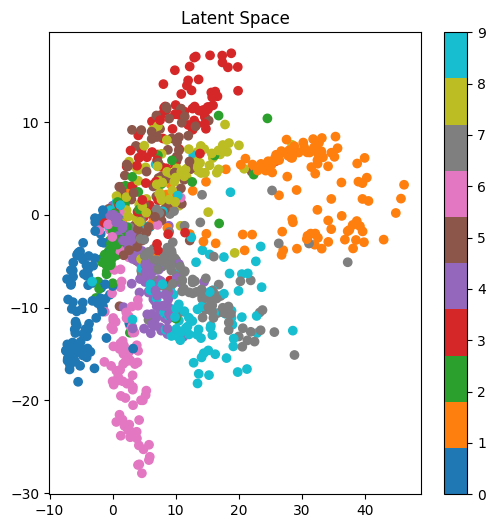

In [6]:
# Visualize latent space
z = encoder.predict(x_train[:1000])

plt.figure(figsize=(6,6))
plt.scatter(z[:,0], z[:,1], c=y_train[:1000], cmap='tab10')
plt.colorbar()
plt.title("Latent Space")
plt.show()